# Global imports

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

from joblib import Parallel, delayed
from numpy import random

import anndata as ann
import joblib
import gseapy as gp
import gc
from scipy.stats import kendalltau, ttest_ind
from matplotlib.colors import TwoSlopeNorm
from sklearn.utils import shuffle
import scanpy as sc

In [2]:
path_dir = '/Users/anwesha/Library/CloudStorage/OneDrive-McGillUniversity/PHD/Research/OverlapAnalysis_thor_pmi_adj/'
prefix_ad = path_dir+'AD/Rosmap/'
prefix_pd = path_dir+ 'PD/Kam/'
prefix_sea = path_dir+'AD/Sea/'
prefix_sm = path_dir+'PD/Sm/'
fp = '/Users/anwesha/Library/CloudStorage/OneDrive-McGillUniversity/PHD/Research/NeuroOverlap/Jan_15/'

In [3]:
deg_path = '/Users/anwesha/Library/CloudStorage/OneDrive-McGillUniversity/PHD/Research/NeuroOverlap/DGE/'

In [4]:
prefix_adata = '/Users/anwesha/Library/CloudStorage/OneDrive-McGillUniversity/PHD/Research/adatas/'

# Utils

In [ ]:
def do_DEGene(adata_,
              celltype,
              groupby='diagnosis',
              use_raw=False,
              layer='lognorm',
              method='wilcoxon',
              groups='all',
              reference='-1',
              thresh_pval = 0.05,
              permute=False,
              permute_idx = None):
    adata = adata_.copy()
    del(adata_)
    sc.pp.regress_out(adata, 'pmi')
    print('DEG cell type', celltype)
    if permute:
        np.random.seed(permute_idx)
        adata.obs['diagnosis'] = adata.obs.groupby('id').diagnosis.transform(lambda x: np.random.choice([1, -1]))
        
    adata.obs[groupby] = adata.obs[groupby].astype(str)
    sc.tl.rank_genes_groups(adata,
                            groupby=groupby,
                            use_raw=use_raw,
                            layer=layer,
                            method=method,
                            groups=groups,
                            reference=reference)
    result = adata.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    degs = pd.DataFrame(
        {group + '_' + key: result[key][group]
        for group in groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
    degs['celltype'] = celltype
    degs.loc[degs['1_pvals_adj']>thresh_pval, '1_logfoldchanges'] = 0
    return degs.pivot(columns = ['1_names'], index='celltype', values = '1_logfoldchanges')

In [ ]:
def do_correlations(merged_all_bs):
    raw_corr_df = pd.DataFrame()

    def _f(_ser):
        return kendalltau(_ser['loading_ad'], _ser['loading_pd'])
    
    print('starting correlations...')
    merged_all_bs = merged_all_bs.fillna(0)
    merged_all_bs.drop(merged_all_bs[(merged_all_bs.loading_ad==0)&(merged_all_bs.loading_pd==0)].index, inplace=True)
    raw_corr_df = merged_all_bs.groupby('celltype_ad_pd').apply(_f)
    raw_corr_df = raw_corr_df.to_frame()
    raw_corr_df.reset_index(inplace=True)
    raw_corr_df['celltype_ad'] = raw_corr_df.celltype_ad_pd.apply(lambda x: x.rsplit('%',1)[0])
    raw_corr_df['celltype_pd'] = raw_corr_df.celltype_ad_pd.apply(lambda x: x.rsplit('%',1)[1])
    raw_corr_df['pearson_corr'] = raw_corr_df[0].apply(lambda x: x[0])
    raw_corr_df['p_value'] = raw_corr_df[0].apply(lambda x: x[1])
    raw_corr_df.drop(columns = ['celltype_ad_pd', 0], inplace = True)
    
    return raw_corr_df

# DGE analysis

## Rosmap-Kamath

In [ ]:
# degs = Parallel(n_jobs=-1)(delayed(do_DEGene)(ad_data[ad_data.obs.celltype==cell], cell) for cell in ad_data.obs.celltype.unique())

In [ ]:
degs_pd = pd.read_csv(deg_path+'dge_pd.csv', index_col=0)
degs_ad = pd.read_csv(deg_path+'dge_ad.csv', index_col=0)

In [ ]:
bs_all_ad = pd.melt(degs_ad, var_name='gene', value_name='loading', ignore_index=False).reset_index()
bs_all_pd = pd.melt(degs_pd, var_name='gene', value_name='loading', ignore_index=False).reset_index()

In [ ]:
merged_all_bs = bs_all_pd.merge(bs_all_ad, on = 'gene', how = 'inner', suffixes = ('_pd', '_ad'))
merged_all_bs['celltype_ad_pd'] = merged_all_bs['celltype_ad'].astype(str)+'%' + merged_all_bs['celltype_pd'].astype(str)

In [ ]:
# merged_all_bs.to_csv(deg_path+'dge_ad_pd_bs.csv')
merged_all_bs = pd.read_csv(deg_path+'dge_ad_pd_bs.csv')

In [ ]:
true_corr = do_correlations(merged_all_bs)
true_corr

starting correlations...


/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_80563/1013912795.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  raw_corr_df = merged_all_bs.groupby('celltype_ad_pd').apply(_f)


,celltype_ad,celltype_pd,pearson_corr,p_value
0,Ast,Astrocyte,0.018713,0.048611
1,Ast,CALB1,0.014641,0.077005
2,Ast,Endothelial,0.016992,0.089277
3,Ast,Ependyma,0.185233,0.006967
4,Ast,Excitatory neuron,0.031416,0.000040
...,...,...,...,...
83,Per,Macrophage,NaN,NaN
84,Per,Microglia,NaN,NaN
85,Per,OPC,NaN,NaN
86,Per,Oligodendrocyte,NaN,NaN


In [ ]:
ct_map_pd = {'Astrocyte':'Ast', 
            'Endothelial':'End', 
            'Ependyma':'Epen',
            'Excitatory neuron':'Ex', 
            'Inhibitory neuron':'In', 
            'Macrophage':'Macro',
            'Microglia':'Mic', 
            'OPC':'Opc', 
            'Oligodendrocyte':'Oli', 
            'CALB1' : 'Calb1',
            'SOX6' : 'Sox6',
        }

In [ ]:
# true_corr = true_corr[~true_corr.celltype_ad.isin(['Per', 'End'])]
true_corr['celltype_pd'] = true_corr.celltype_pd.replace(ct_map_pd)

In [ ]:
true_corr = true_corr[~true_corr.celltype_ad.isin(['Per', 'End'])]
true_corr = true_corr[~true_corr.celltype_pd.isin(['Epen', 'Macro'])]

Ast      0.113976
Calb1    0.104822
End      0.121434
Ex       0.094554
In       0.107709
Mic      0.087456
Oli      0.096001
Opc      0.165161
Sox6     0.099243
dtype: float64


Text(1143.7222222222222, 0.5, 'AD cell-type')

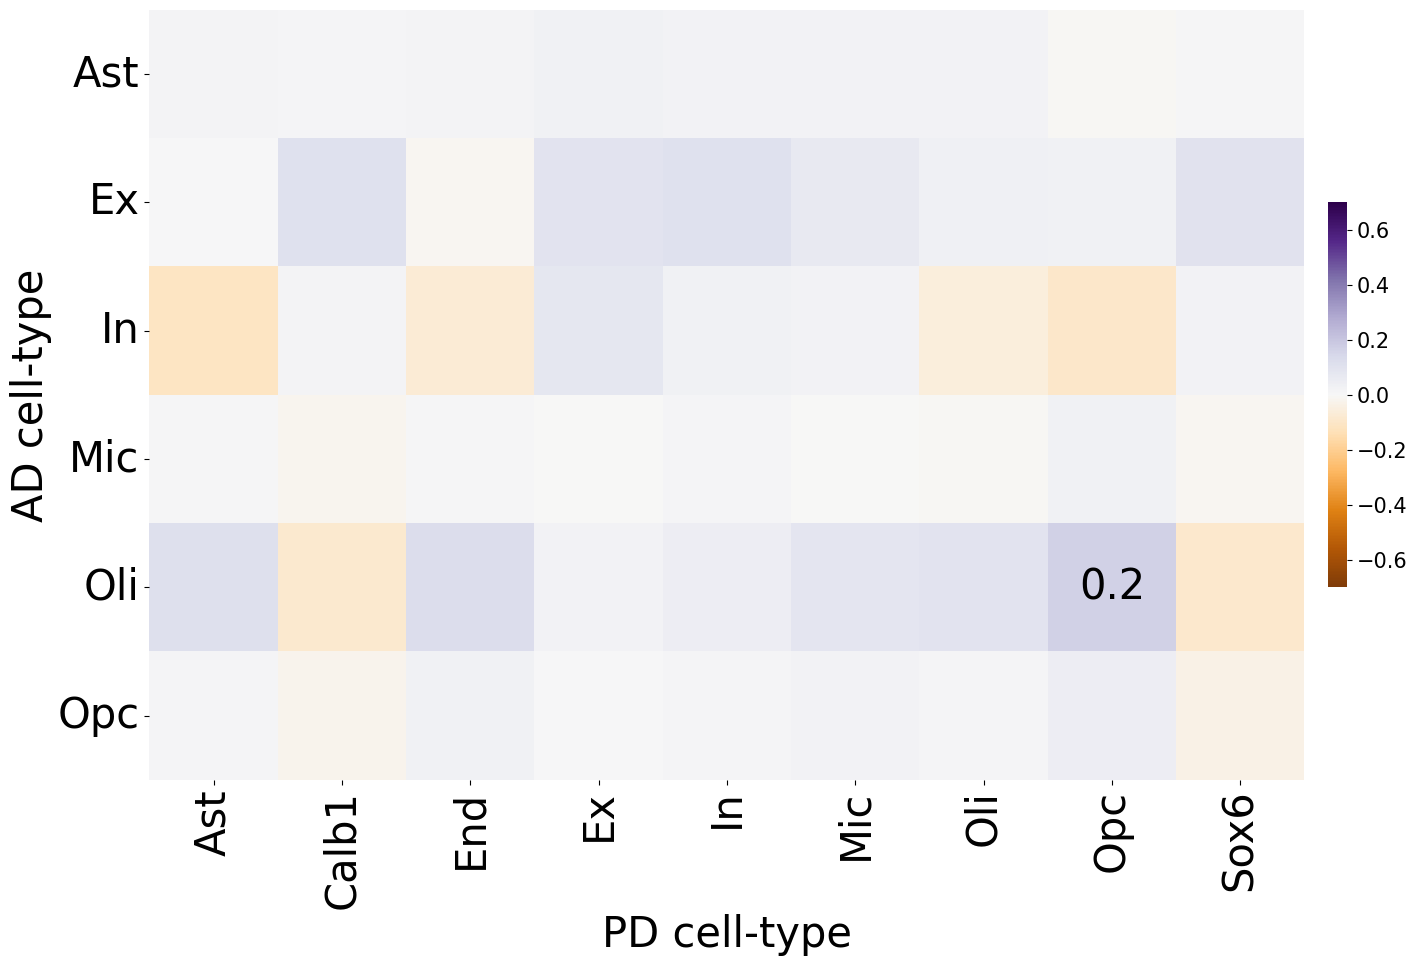

In [ ]:
norm = TwoSlopeNorm(vmin=-0.7, vmax=0.7, vcenter=0)
_corr_df = true_corr.astype({'pearson_corr':'float64'})
_temp = _corr_df.pivot(index = ['celltype_ad'], columns=['celltype_pd'], values = ['pearson_corr'])
_temp = _temp.sort_index(axis = 0)
_temp = _temp.sort_index(axis = 1)
_temp.columns = _temp.columns.droplevel(0) #remove amount
_temp.columns.name = None               #remove categories
_temp = _temp.reset_index() 
_temp.set_index('celltype_ad', inplace = True)

fs = 30
print(_temp.max())
fig, ax = plt.subplots(figsize=(30,10))    
sns.heatmap(_temp, cmap = 'PuOr', square = True, norm=norm, annot_kws={"size": 16}, cbar_kws={"shrink": 0.5, 'pad':0.01,} )
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
ax.tick_params(labelsize=fs)

cax = ax.figure.axes[-1]
cax.tick_params(labelsize=fs-15)

mtx = _temp
for i in range(mtx.shape[0]):
    for j in range(mtx.shape[1]):
        if abs(mtx.iloc[i, j]) >= min(0.3, mtx.abs().max().max()):
            ax.text(j + 0.5, i + 0.5, f'{mtx.iloc[i, j]:.1f}', 
                    horizontalalignment='center', 
                    verticalalignment='center', 
                    fontsize=fs,
                    color='white' if mtx.iloc[i, j] > 70 else 'black')
ax.set_xlabel('PD cell-type', fontsize=fs)
ax.set_ylabel('AD cell-type', fontsize=fs)

In [ ]:
perm_corr = pd.read_csv('/Users/anwesha/Library/CloudStorage/OneDrive-McGillUniversity/PHD/Research/NeuroOverlap/DGE/permutation_thresh_95_100.csv')

In [ ]:
perm_corr.head(2), true_corr.head(2)

(   Unnamed: 0 celltype_ad celltype_pd  high_percentile  low_percentile
 0           0         Ast   Astrocyte         0.030833       -0.040319
 1           1         Ast       CALB1         0.033179       -0.034076,
   celltype_ad celltype_pd  pearson_corr   p_value
 0         Ast         Ast      0.018713  0.048611
 1         Ast       Calb1      0.014641  0.077005)

In [ ]:
perm_corr['celltype_pd'] = perm_corr.celltype_pd.replace(ct_map_pd)
perm_corr.drop(perm_corr[perm_corr.celltype_ad.isin(['Per', 'End'])].index, inplace=True)

In [ ]:
perm_corr.drop(perm_corr[perm_corr.celltype_pd.isin(['Macro', 'Epen'])].index, inplace=True)

In [ ]:
merged_corr =  perm_corr[['celltype_ad', 'celltype_pd', 'high_percentile', 'low_percentile']].merge(true_corr, on = ['celltype_ad', 'celltype_pd'], how = 'outer')

In [ ]:
merged_corr['thresh_corr'] = merged_corr.apply(lambda x: 0 if (x.pearson_corr < x.high_percentile) & (x.pearson_corr > x.low_percentile) else x.pearson_corr, axis=1)

Ast      0.113976
Calb1    0.000000
End      0.121434
Ex       0.031416
In       0.024762
Mic      0.087456
Oli      0.096001
Opc      0.165161
Sox6     0.099243
dtype: float64


Text(1050.7222222222224, 0.5, 'AD cell-type')

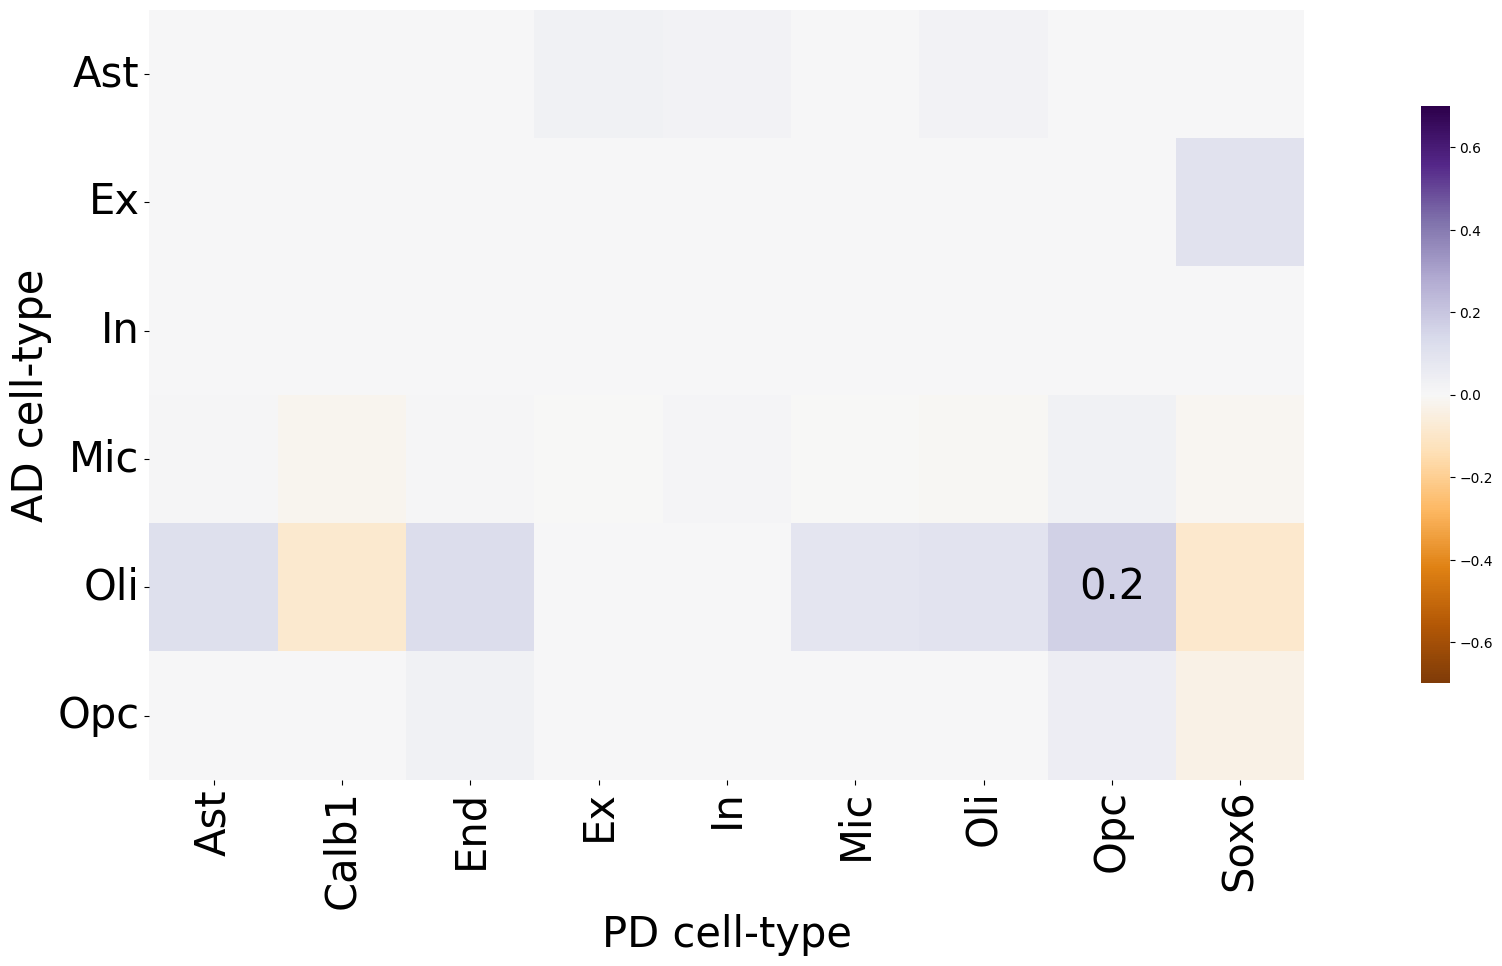

In [ ]:
norm = TwoSlopeNorm(vmin=-0.7, vmax=0.7, vcenter=0)
_corr_df = merged_corr.astype({'thresh_corr':'float64'})
_temp = _corr_df.pivot(index = ['celltype_ad'], columns=['celltype_pd'], values = ['thresh_corr'])
_temp = _temp.sort_index(axis = 0)
_temp = _temp.sort_index(axis = 1)
_temp.columns = _temp.columns.droplevel(0) #remove amount
_temp.columns.name = None               #remove categories
_temp = _temp.reset_index() 
_temp.set_index('celltype_ad', inplace = True)

fs = 30
print(_temp.max())
fig, ax = plt.subplots(figsize=(30,10))    
sns.heatmap(_temp, cmap = 'PuOr', square = True, norm=norm, annot_kws={"size": 16}, cbar_kws={"shrink": 0.75, 'pad':0.05,})
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
ax.tick_params(labelsize=fs)

cax = ax.figure.axes[-1]
cax.tick_params(labelsize=fs-20)

mtx = _temp
for i in range(mtx.shape[0]):
    for j in range(mtx.shape[1]):
        if abs(mtx.iloc[i, j]) >= min(0.3, mtx.abs().max().max()):
            ax.text(j + 0.5, i + 0.5, f'{mtx.iloc[i, j]:.1f}', 
                    horizontalalignment='center', 
                    verticalalignment='center', 
                    fontsize=fs,
                    color='white' if mtx.iloc[i, j] > 70 else 'black')
ax.set_xlabel('PD cell-type', fontsize=fs)
ax.set_ylabel('AD cell-type', fontsize=fs)

In [ ]:
plt.rcParams['svg.fonttype'] = 'none'

In [ ]:
fig.savefig(fp+'RK_DEGene.png', bbox_inches='tight', dpi=300)
fig.savefig(fp+'RK_DEGene.svg', bbox_inches='tight', )

In [ ]:
# bs_all_ad.to_csv(prefix_ad+'DEGenes/DEGenes_Wilcoxon/loadings_wilcoxon.csv')
# bs_all_pd.to_csv(prefix_pd+'DEGenes/DEGenes_Wilcoxon/loadings_wilcoxon.csv')

In [ ]:
pd_d = 'Kam'
ad_d = 'Rosmap'
corr_mtx = pd.read_csv(f'/Users/anwesha/Library/CloudStorage/OneDrive-McGillUniversity/PHD/Research/OverlapAnalysis_thor_pmi_adj/PD_AD/{pd_d}_{ad_d}/doOR_False/correlation_PD_AD_kendalltau_42seed_FalsedoOR.csv_1000thresholded_97.5highper_2.5lowper.csv')

In [ ]:
corr_mtx.rename(columns={'cell_comp_PDKam': 'celltype_pd', 'cell_comp_ADRosmap':'celltype_ad', 'kendalltau_corr': 'pearson_corr'}, inplace=True)

In [ ]:
merged_df = pd.concat([corr_mtx[['celltype_ad', 'celltype_pd', 'pearson_corr']].assign(method='PLS-DA'), true_corr[['celltype_ad', 'celltype_pd', 'pearson_corr']].assign(method='DGE')])

In [ ]:
merged_df.reset_index(drop=True, inplace=True)

Text(0, 0.5, 'count')

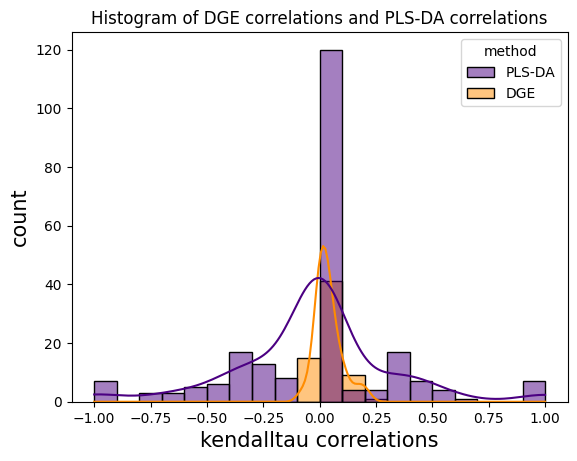

In [ ]:
ax = sns.histplot(merged_df, x = 'pearson_corr', hue = 'method', kde=True, bins=20, palette=['indigo', 'darkorange'])
ax.set_title('Histogram of DGE correlations and PLS-DA correlations')
ax.set_xlabel('kendalltau correlations', fontsize = 15)
ax.set_ylabel('count', fontsize=15)

## Smijac and Seattle

In [ ]:
degs_sea = pd.read_csv(deg_path+'degs_sea.csv')
degs_sm = pd.read_csv(deg_path+'degs_sm.csv')

In [ ]:
bs_all_ad = pd.melt(degs_sea, var_name='gene', value_name='loading', ignore_index=False).reset_index()
bs_all_pd = pd.melt(degs_sm, var_name='gene', value_name='loading', ignore_index=False).reset_index()

In [ ]:
merged_all_bs = bs_all_pd.merge(bs_all_ad, on = 'gene', how = 'inner', suffixes = ('_pd', '_ad'))
merged_all_bs['celltype_ad_pd'] = merged_all_bs['celltype_ad'].astype(str)+'%' + merged_all_bs['celltype_pd'].astype(str)

In [ ]:
true_corr = do_correlations(merged_all_bs)
true_corr

starting correlations...


,celltype_ad,celltype_pd,pearson_corr,p_value
0,astro,Astrocyte,0.064610,1.511274e-17
1,astro,CADPS2+ neurons,NaN,NaN
2,astro,DaNs,0.022990,3.106573e-03
3,astro,Endothelial cells,-0.031668,4.002861e-05
4,astro,Ependymal,-0.013150,8.994046e-02
...,...,...,...,...
91,vip,Inhibitory neuron,0.068648,2.481286e-22
92,vip,Microglia,0.020477,4.578744e-03
93,vip,OPC,-0.034138,2.821471e-06
94,vip,Oligodendrocytes,-0.019897,3.625626e-03


In [ ]:
# true_corr = true_corr[~true_corr.celltype_pd.isin(['CADPS2+ neurons'])]
true_corr['celltype_pd'] = true_corr.celltype_pd.replace({'Astrocyte':'Ast', 
                                             'Endothelial cells':'End', 
                                             'Ependymal':'Epen',
                                             'Excitatory neuron':'Ex', 
                                             'Inhibitory neuron':'In', 
                                             'Macrophage':'Macro',
                                            'Microglia':'Mic', 
                                            'OPC':'Opc', 
                                            'Oligodendrocytes':'Oli', 
                                            'Pericytes':'Per',
                                            })

Ast     0.109989
DaNs    0.114759
End     0.065556
Epen    0.058456
Ex      0.100927
GABA    0.062053
In      0.093241
Mic     0.266001
Oli     0.265096
Opc     0.085231
Per     0.051873
dtype: float64


Text(2421.2065972222226, 0.5, 'AD celltypes: DE wilcoxon')

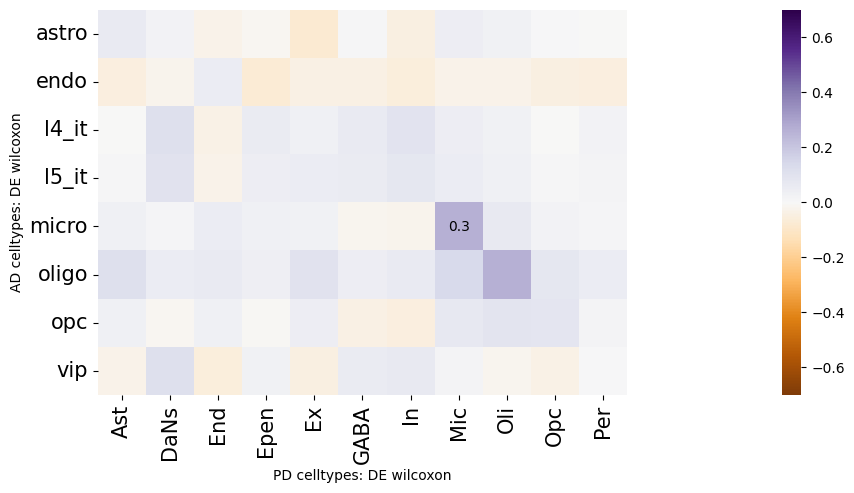

In [ ]:
norm = TwoSlopeNorm(vmin=-0.7, vmax=0.7, vcenter=0)
_corr_df = true_corr.astype({'pearson_corr':'float64'})
_temp = _corr_df.pivot(index = ['celltype_ad'], columns=['celltype_pd'], values = ['pearson_corr'])
_temp.drop(columns=(('pearson_corr','CADPS2+ neurons')), inplace=True)
_temp = _temp.sort_index(axis = 0)
_temp = _temp.sort_index(axis = 1)
_temp.columns = _temp.columns.droplevel(0) #remove amount
_temp.columns.name = None               #remove categories
_temp = _temp.reset_index() 
_temp.set_index('celltype_ad', inplace = True)

print(_temp.max())
fig, ax = plt.subplots(figsize=(40,5))    
sns.heatmap(_temp, cmap = 'PuOr', square = True, norm=norm,)
ax.tick_params(labelsize=15)
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
mtx = _temp
for i in range(mtx.shape[0]):
    for j in range(mtx.shape[1]):
        if abs(mtx.iloc[i, j]) >= min(0.3, mtx.abs().max().max()):
            ax.text(j + 0.5, i + 0.5, f'{mtx.iloc[i, j]:.1f}', 
                    horizontalalignment='center', 
                    verticalalignment='center', 
                    color='white' if mtx.iloc[i, j] > 70 else 'black')
ax.set_xlabel('PD celltypes: DE wilcoxon')
ax.set_ylabel('AD celltypes: DE wilcoxon')

In [ ]:
fig.savefig(fp+'SS_DEGene.png', bbox_inches='tight', dpi=300)
fig.savefig(fp+'SS_DEGene.svg', bbox_inches='tight', )

In [ ]:
plsr_corr = pd.read_csv('/Users/anwesha/Library/CloudStorage/OneDrive-McGillUniversity/PHD/Research/OverlapAnalysis_thor_pmi_adj/PD_AD/Sm_Sea/doOR_False/correlation_PD_AD_kendalltau_42seed_FalsedoOR_true_loading.csv')

In [ ]:
pd_d = 'Sm'
ad_d = 'Sea'
corr_mtx = pd.read_csv(f'/Users/anwesha/Library/CloudStorage/OneDrive-McGillUniversity/PHD/Research/OverlapAnalysis_thor_pmi_adj/PD_AD/{pd_d}_{ad_d}/doOR_False/correlation_PD_AD_kendalltau_42seed_FalsedoOR.csv_1000thresholded_97.5highper_2.5lowper.csv')

In [ ]:
corr_mtx.rename(columns={'cell_comp_PDSm': 'celltype_pd', 'cell_comp_ADSea':'celltype_ad', 'kendalltau_corr': 'pearson_corr'}, inplace=True)

In [ ]:
merged_df = pd.concat([corr_mtx[['celltype_ad', 'celltype_pd', 'pearson_corr']].assign(method='PLS-DA'), true_corr[['celltype_ad', 'celltype_pd', 'pearson_corr']].assign(method='DGE')])

In [ ]:
merged_df.reset_index(drop=True, inplace=True)

Text(0, 0.5, 'count')

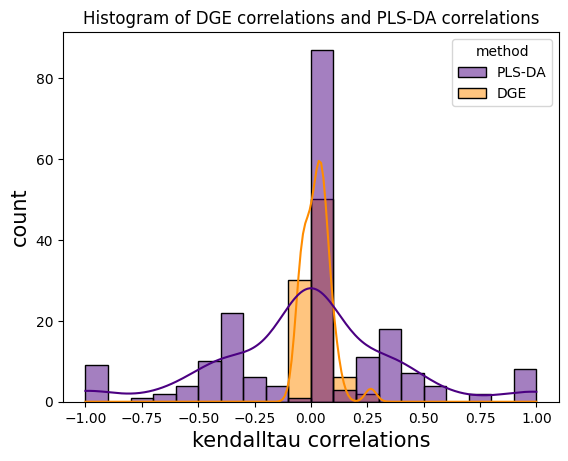

In [ ]:
ax = sns.histplot(merged_df, x = 'pearson_corr', hue = 'method', kde=True, bins=20, palette=['indigo', 'darkorange'])
ax.set_title('Histogram of DGE correlations and PLS-DA correlations')
ax.set_xlabel('kendalltau correlations', fontsize = 15)
ax.set_ylabel('count', fontsize=15)

# GSEA

In [ ]:
# perform GSEA for each component in the model
def do_gsea(celltype, gene_set_list, pls_df, seed = None, do_shuffle=False):
    print(celltype.upper())
    loadings_df = pls_df[pls_df.celltype == celltype][['loading', 'gene']]
    gsea_terms_tmp_comp = pd.DataFrame()
    # perform GSEA using multiple gene set databases
    for gene_set in gene_set_list:
        loadings = loadings_df['loading'].values
        gene_symbol = loadings_df['gene'].values
        gene_symbol = gene_symbol[loadings!=0]
        loadings = loadings[loadings!=0]
        if do_shuffle:
            loadings = shuffle(loadings, random_state=seed)
        ranked_genes = pd.DataFrame(data={'genes':gene_symbol, 
                                        'PLS_weights': loadings})
        pre_res = None
        try:
            pre_res = gp.prerank(rnk=ranked_genes,
                            gene_sets=gene_set,
                            processes=4,
                            min_size=5, 
                            # max_size=1000,
                            no_plot=True,
                            permutation_num=1000,
                            outdir=None,
                            seed=1)
        except Exception:
            print(f'GSEA Error: No enriched gene modules found in celltype {celltype}')
        
        if pre_res:
            df = pre_res.res2d
            df['gene_set_source'] = gene_set
            df = df[df['FDR q-val']<0.05]
            df = df[~df['NOM p-val'].isna()]
            df['celltype'] = celltype
            df = df.sort_values('NES', ascending=False)
            if not df.empty:
                gsea_terms_tmp_comp = pd.concat((gsea_terms_tmp_comp, df), axis=0)
    return gsea_terms_tmp_comp

In [ ]:
gene_set_list = ['GO_Biological_Process_2023', 'GO_Molecular_Function_2023', 'GO_Cellular_Component_2023']

In [ ]:
gsea_terms_ad = Parallel(n_jobs=4, verbose = 10)(delayed(do_gsea)(celltype, gene_set_list, bs_all_ad, seed = 0) for celltype in bs_all_ad.celltype.unique())

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


EX
OLI
IN
MIC


/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
2024-01-24 19:41:08,173 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
2024-01-24 19:41:08,330 [WARNING] Duplicated values found in preranked stats: 0.03% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: Depreca

GSEA Error: No enriched gene modules found in celltype Mic
OPC


/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
[Parallel(n_jobs=4)]: Done   2 out of   8 | elapsed:    2.0s remaining:    6.0s
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads


AST


/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
[Parallel(n_jobs=4)]: Done   3 out of   8 | elapsed:    2.3s remaining:    3.8s
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
[Parallel(n_jobs=4)]: Done   4 out of   8 | elapsed:    2.3s remaining:    2.3s


END
GSEA Error: No enriched gene modules found in celltype End
GSEA Error: No enriched gene modules found in celltype End
GSEA Error: No enriched gene modules found in celltype End
PER
GSEA Error: No enriched gene modules found in celltype Per
GSEA Error: No enriched gene modules found in celltype Per
GSEA Error: No enriched gene modules found in celltype Per


/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
[Parallel(n_jobs=4)]: Done   5 out of   8 | elapsed:    2.4s remaining:    1.4s
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
[Parallel(n_jobs=4)]: Done   6 out of   8 | elapsed:    3.1s remaining:    1.0s
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads


In [ ]:
gsea_terms_pd = Parallel(n_jobs=4, verbose = 10)(delayed(do_gsea)(celltype, gene_set_list, bs_all_pd, seed = 0) for celltype in bs_all_pd.celltype.unique())

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
2024-01-24 19:41:31,319 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
2024-01-24 19:41:31,330 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads


SOX6
CALB1
ASTROCYTE
ENDOTHELIAL


/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/opt/anaconda3/envs/scrnaseq/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


MICROGLIA


/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/opt/anaconda3/envs/scrnaseq/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


...

/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
2024-01-24 19:43:27,623 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
[Parallel(n_jobs=4)]: Done   6 out of  11 | elapsed:  2.0min remaining:  1.7min
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads


INHIBITORY NEURON


/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
2024-01-24 19:44:03,381 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
2024-01-24 19:44:19,048 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/opt/anaconda3/envs/scrnaseq/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: p

EPENDYMA


/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
[Parallel(n_jobs=4)]: Done   8 out of  11 | elapsed:  3.0min remaining:  1.1min
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
2024-01-24 19:44:39,701 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000gn/T/ipykernel_45543/2229635983.py:18: DeprecationWarning: processes is deprecated; use threads
/var/folders/gk/1fbsbgwj76g1p4mcnfmxmhpw0000g

In [ ]:
gsea_df_ad = pd.DataFrame()
for _df in gsea_terms_ad:
    gsea_df_ad = pd.concat([gsea_df_ad, _df])

gsea_df_pd = pd.DataFrame()
for _df in gsea_terms_pd:
    gsea_df_pd = pd.concat([gsea_df_pd, _df])

In [ ]:
gsea_df = gsea_df_ad.merge(gsea_df_pd, on = 'Term', how = 'inner', suffixes=('_ad', '_pd'))
gsea_df[gsea_df.gene_set_source_pd=='GO_Biological_Process_2023'].Term.unique()

array(['Cytoplasmic Translation (GO:0002181)', 'Translation (GO:0006412)',
       'Peptide Biosynthetic Process (GO:0043043)',
       'Macromolecule Biosynthetic Process (GO:0009059)',
       'Mitochondrial Respiratory Chain Complex Assembly (GO:0033108)',
       'NADH Dehydrogenase Complex Assembly (GO:0010257)',
       'Mitochondrial Respiratory Chain Complex I Assembly (GO:0032981)'],
      dtype=object)

In [ ]:
gsea_df = pd.read_csv(deg_path+'gsea_df_merged.csv')

In [ ]:
gsea_df = gsea_df.drop(gsea_df[gsea_df.celltype_pd=='Macrophage'].index)

In [ ]:
gsea_df['celltype_ad_pd'] = gsea_df['celltype_ad'].astype(str)+'%' + gsea_df['celltype_pd'].astype(str)

In [ ]:
ct_map = {'ast': 'Ast',
          'end': 'End',
          'per' : 'Per',
          'oli': 'Oli',
          'opc': 'Opc',
          'end': 'End',
          'ex': 'Ex',
          'in':'In',
          'macro':'Macro',
}

In [ ]:
def ct_map_f(x):
    for k, v in ct_map.items():
        if k in x.lower():
            return v
    return x

gsea_df.loc[:, 'celltype_ad_pd'] = gsea_df.celltype_ad_pd.map(lambda x: ' '.join([ct_map_f(x.rsplit('%', 1)[0]), ct_map_f(x.rsplit('%', 1)[1])]))

In [ ]:
gsea_df['Term'] = gsea_df['Term'].map(lambda x: x.rsplit(' (GO', 1)[0])

In [ ]:
import textwrap

In [ ]:
gsea_df.Term.unique().shape

(19,)

In [ ]:
ax.get_legend().get_title()

Text(0, 0, 'gene ontology')

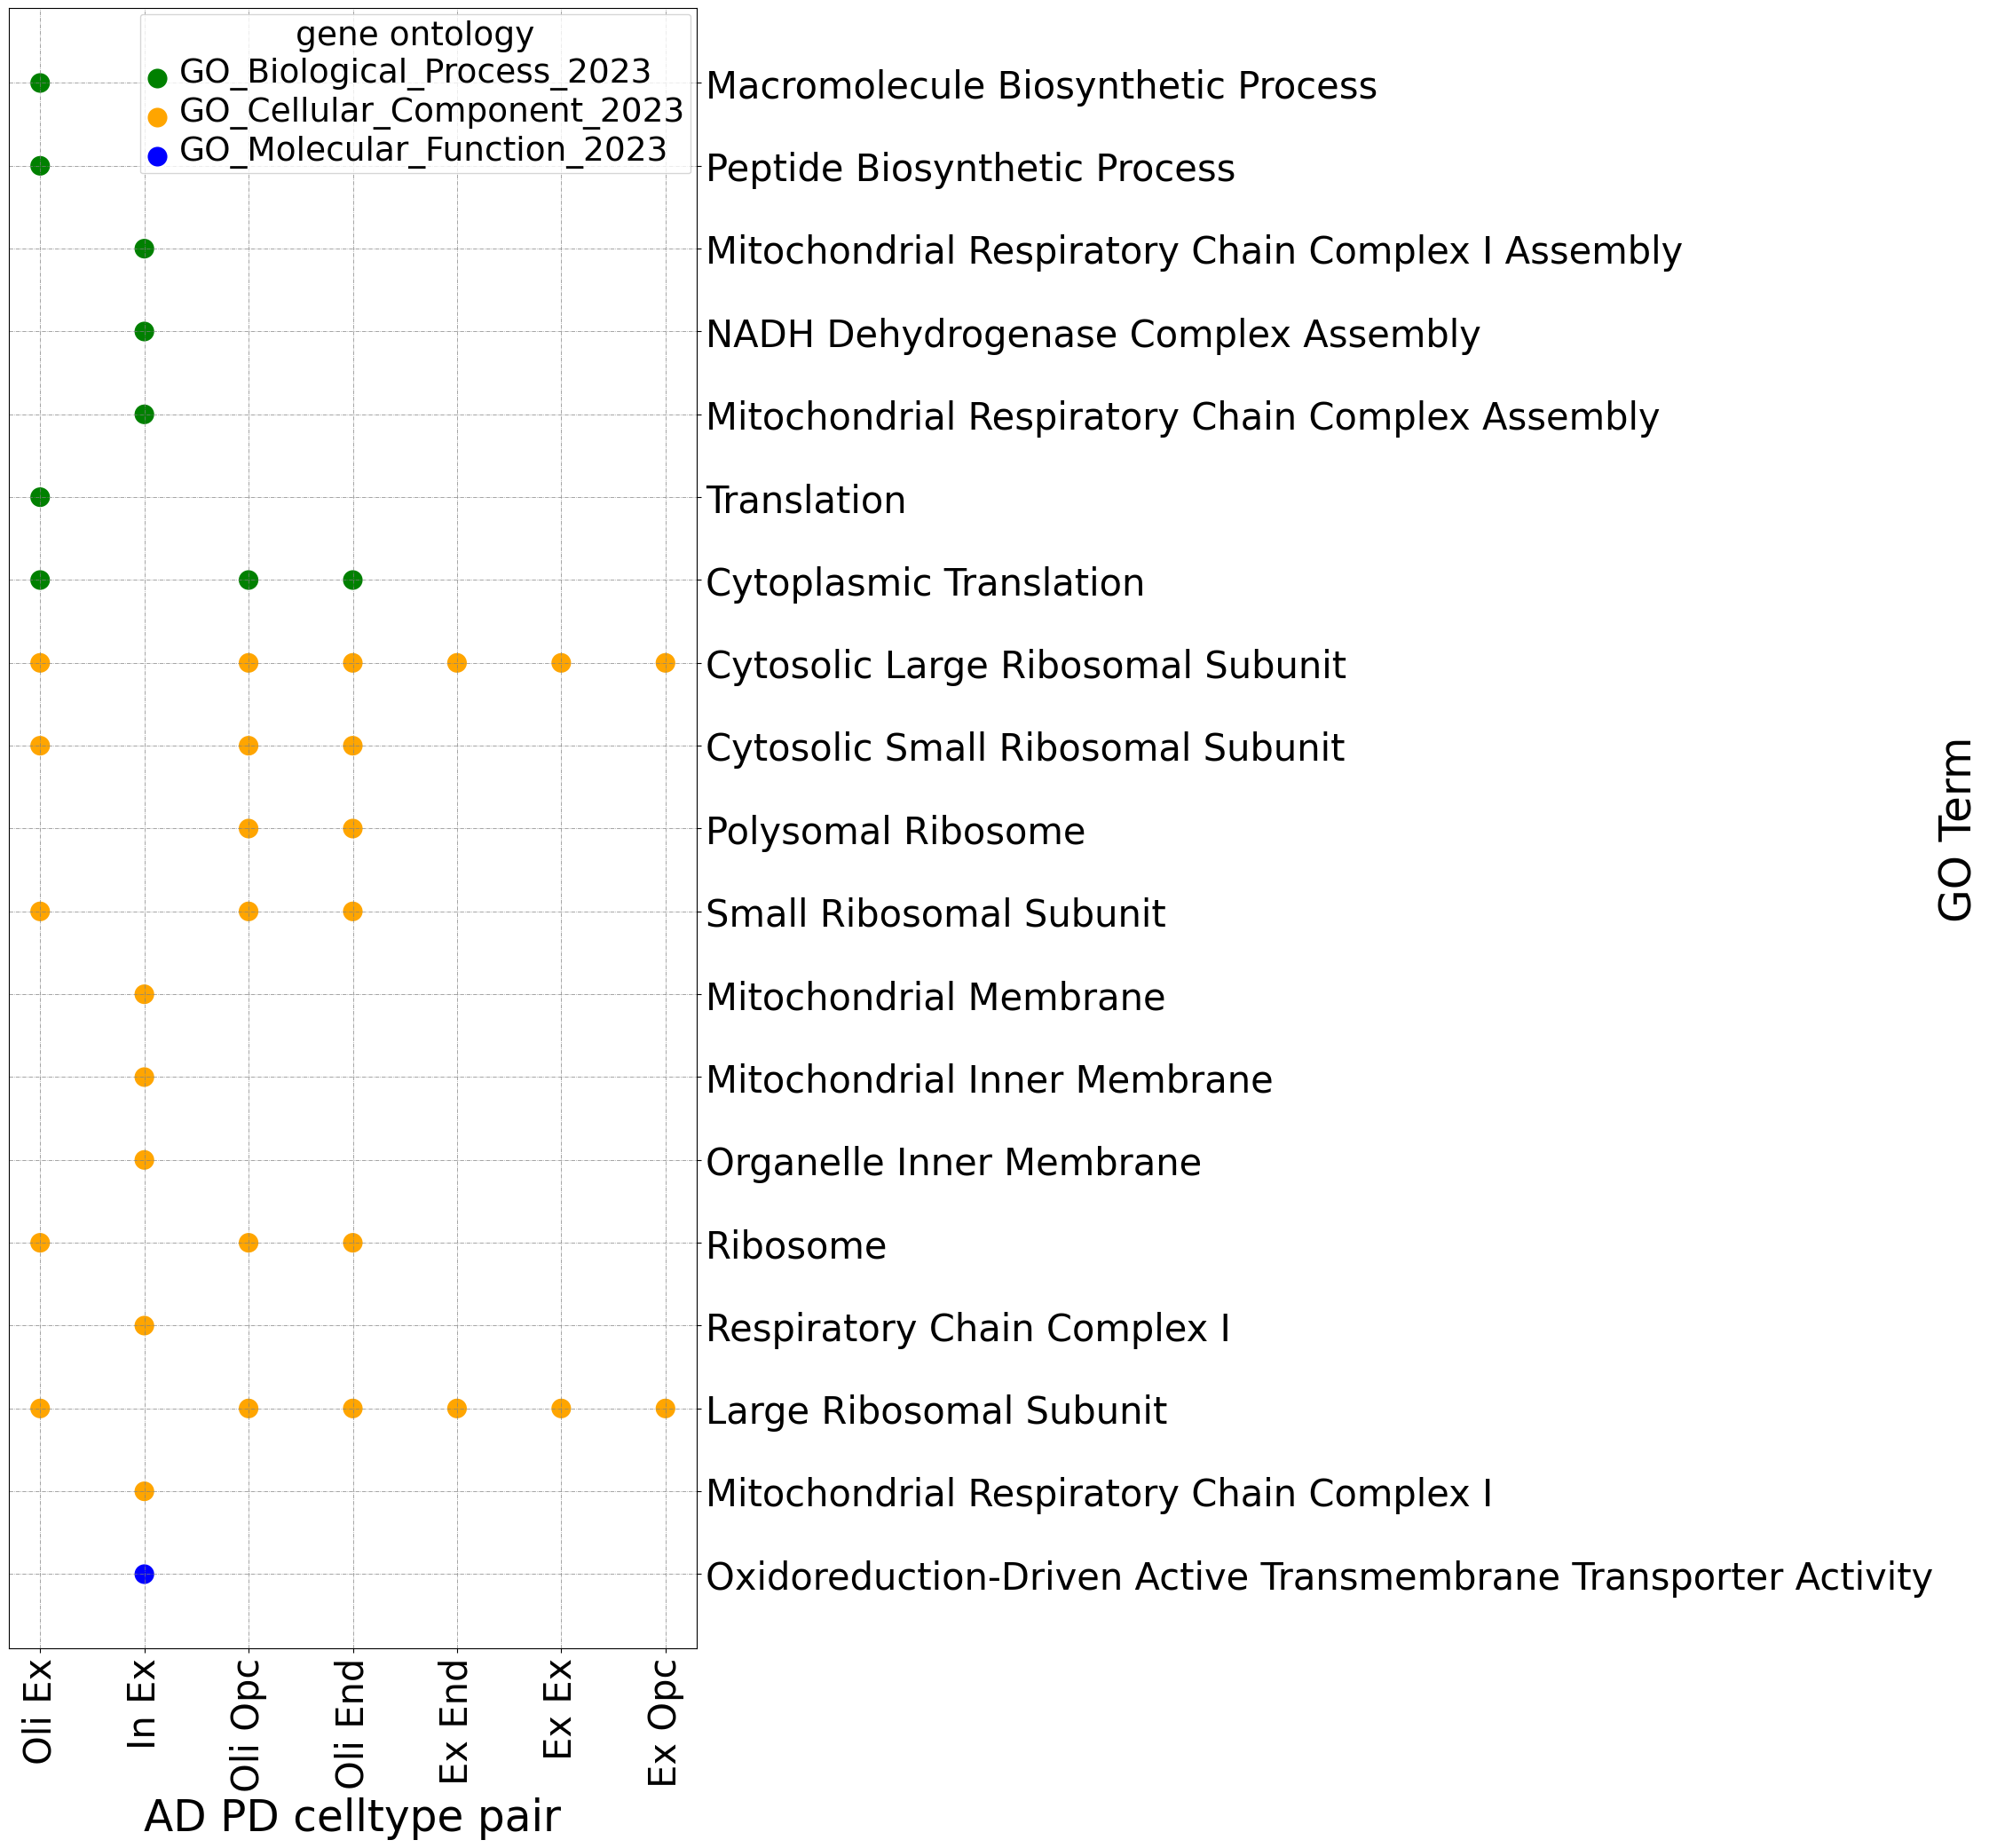

In [ ]:
gsea_df.rename(columns={'gene_set_source_pd':'gene ontology'}, inplace=True)
f, ax = plt.subplots(figsize=(10, 24))
fs = 35
_ = sns.scatterplot(gsea_df.sort_values('gene ontology'), hue = 'gene ontology', y = 'Term', x = 'celltype_ad_pd', color = 'indigo', s =300, palette=['green', 'orange', 'blue'], ax=ax)
ax.tick_params(axis='x', rotation=90)
ax.yaxis.set_label_position("right")
ax.yaxis.set_ticks_position("right")
# _ = ax.set_yticklabels([textwrap.fill(w.get_text(), width=30) for w in ax.get_yticklabels()], ha='right', va='top')
ax.tick_params(labelsize=fs-5)
_ = ax.set_xlabel('AD PD celltype pair', fontsize=fs)
_ = ax.set_ylabel('GO Term', fontsize=fs)

# ax.legend(labels=['Total genes', 'Robust genes'], title='BS genes')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.setp(ax.get_legend().get_texts(), fontsize=fs-8) # for legend text
_ = plt.setp(ax.get_legend().get_title(), fontsize=fs-8)
plt.grid(color = 'gray', linestyle = '-.', linewidth = 0.5)

In [ ]:
f.savefig(deg_path+'gsea.svg')